## About the Dataset

https://www.kaggle.com/datasets/amar5693/screen-time-sleep-and-stress-analysis-dataset?resource=download

Smartphone Usage, Productivity & Lifestyle Analytics Dataset (50K Records)

This dataset contains 50,000 user records analyzing smartphone usage behavior and its relationship with productivity, sleep patterns, and stress levels. It is designed for machine learning, statistical analysis, and behavioral research.

In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [12]:
df = pd.read_csv("Smartphone_Usage_Productivity_Dataset.csv")
df

,user_id,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,U1,58,Male,Professional,Android,1.3,6.7,6,8.8,4,42,1,8.7
1,U2,25,Male,Professional,Android,1.2,1.5,5,6.4,1,51,3,5.1
2,U3,19,Male,Student,iOS,5.3,5.7,5,9.0,4,14,5,6.3
3,U4,35,Female,Business Owner,iOS,5.8,2.5,2,5.7,3,36,6,12.8
4,U5,33,Male,Freelancer,Android,7.9,1.3,4,5.7,3,37,5,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,U49996,44,Male,Business Owner,Android,5.9,5.4,5,6.6,1,11,5,3.0
49996,U49997,42,Other,Business Owner,Android,2.9,7.4,9,6.3,2,20,4,6.2
49997,U49998,27,Female,Freelancer,iOS,1.4,2.5,4,6.7,9,39,4,5.1
49998,U49999,41,Female,Business Owner,iOS,8.9,3.0,6,5.5,2,51,0,9.2


In [13]:
print(df.shape)
print(df.info())

(50000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   user_id                    50000 non-null  object 
 1   Age                        50000 non-null  int64  
 2   Gender                     50000 non-null  object 
 3   Occupation                 50000 non-null  object 
 4   Device_Type                50000 non-null  object 
 5   Daily_Phone_Hours          50000 non-null  float64
 6   Social_Media_Hours         50000 non-null  float64
 7   Work_Productivity_Score    50000 non-null  int64  
 8   Sleep_Hours                50000 non-null  float64
 9   Stress_Level               50000 non-null  int64  
 10  App_Usage_Count            50000 non-null  int64  
 11  Caffeine_Intake_Cups       50000 non-null  int64  
 12  Weekend_Screen_Time_Hours  50000 non-null  float64
dtypes: float64(4), int64(5), object(4)

In [14]:
print(df.describe())

                Age  Daily_Phone_Hours  Social_Media_Hours  \
count  50000.000000       50000.000000        50000.000000   
mean      39.034960           6.509116            4.267250   
std       12.414877           3.170903            2.164743   
min       18.000000           1.000000            0.500000   
25%       28.000000           3.800000            2.400000   
50%       39.000000           6.500000            4.300000   
75%       50.000000           9.200000            6.100000   
max       60.000000          12.000000            8.000000   

       Work_Productivity_Score   Sleep_Hours  Stress_Level  App_Usage_Count  \
count             50000.000000  50000.000000  50000.000000      50000.00000   
mean                  5.503760      6.497744      5.504500         32.43898   
std                   2.874806      1.449551      2.871095         16.12151   
min                   1.000000      4.000000      1.000000          5.00000   
25%                   3.000000      5.200000  

In [15]:
df[df.isnull().any(axis=1)]

,user_id,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours


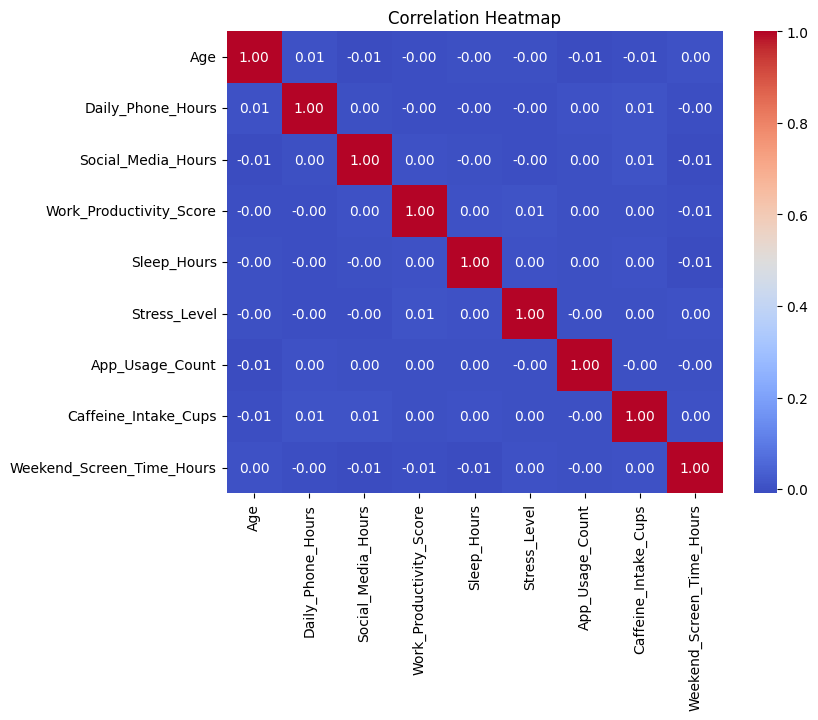

In [16]:
#corelation Heatmap

# compute correlation matrix
corr = df.corr(numeric_only=True)

# plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

## Hanlde Missing Values
There are no numm values

In [9]:
#drop unnessassary columns
df = df.drop(columns=['user_id'], axis=1)

# Finding Numeric and categorical columns

In [10]:
num_cols = df.select_dtypes(include='number').columns
cat_cols = df.select_dtypes(exclude='number').columns

print('Numberic:', len(num_cols))
print('Categorical:', len(cat_cols))



Numberic: 9
Categorical: 3


## Encoding

In [11]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import LabelEncoder

In [12]:
from sklearn.preprocessing import LabelEncoder

# 3 categorical columns
cat_cols = ['Gender', 'Occupation', 'Device_Type']

# Encode each column in-place
for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])  # fill NaNs with mode
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

print(df[cat_cols].head())

   Gender  Occupation  Device_Type
0       1           2            0
1       1           2            0
2       1           3            1
3       0           0            1
4       1           1            0


In [13]:
df

,Age,Gender,Occupation,Device_Type,Daily_Phone_Hours,Social_Media_Hours,Work_Productivity_Score,Sleep_Hours,Stress_Level,App_Usage_Count,Caffeine_Intake_Cups,Weekend_Screen_Time_Hours
0,58,1,2,0,1.3,6.7,6,8.8,4,42,1,8.7
1,25,1,2,0,1.2,1.5,5,6.4,1,51,3,5.1
2,19,1,3,1,5.3,5.7,5,9.0,4,14,5,6.3
3,35,0,0,1,5.8,2.5,2,5.7,3,36,6,12.8
4,33,1,1,0,7.9,1.3,4,5.7,3,37,5,9.9
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,44,1,0,0,5.9,5.4,5,6.6,1,11,5,3.0
49996,42,2,0,0,2.9,7.4,9,6.3,2,20,4,6.2
49997,27,0,1,1,1.4,2.5,4,6.7,9,39,4,5.1
49998,41,0,0,1,8.9,3.0,6,5.5,2,51,0,9.2


## Data Imputation

In [14]:
#numeric to median
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Fill all categorical columns with mode

# Here we need to user median for categorical columns as all are now converted to numeric values
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].median())


print(df[cat_cols].head())

   Gender  Occupation  Device_Type
0       1           2            0
1       1           2            0
2       1           3            1
3       0           0            1
4       1           1            0


In [15]:
# #print(df.isnull())
# null_rows = df[df.isnull().any(axis=1)]
# print(null_rows)

## Train_Test_Split

In [16]:
target = "Stress_Level"

In [17]:
#seperate X and Y
X = df.drop(target, axis=1)
y = df[target]

In [18]:
#Training and Testing Data (divide the data into two part)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test =train_test_split(X,y,test_size=.3, random_state=42)

## Normalize / Standardize
I choose to standardize as in some columns we have some outliers

In [19]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X)
X_train_scaled = scaler.transform(X_test)

### Cross Validation
We must do cross-validation as we want to avoid overfitting
Instead of one tran/test split we will use K-fold CV as it will help us to iterate through all the datapoints in the dataset

In [20]:
from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train models and evalaute all models one-by-one

In [21]:
#Linear Regression
lr = LinearRegression()
lr.fit(X_train, y_train)

pred_lr = lr.predict(X_test)

rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
mae_lr = mean_absolute_error(y_test, pred_lr)
r2_lr = r2_score(y_test, pred_lr)

print("LinearRegression")
print("RMSE:", rmse_lr)
print("MAE:", mae_lr)
print("R2:", r2_lr)


LinearRegression
RMSE: 2.874343979598122
MAE: 2.5030574430717816
R2: -0.0006207309141208484


In [22]:
#KNN Regressor
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

pred_knn = knn.predict(X_test)

print("\nKNN")

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_knn)))
print("MAE:", mean_absolute_error(y_test, pred_knn))
print("R2:", r2_score(y_test, pred_knn))



KNN
RMSE: 3.17725290148581
MAE: 2.686493333333333
R2: -0.22263151572704953


In [23]:
#DECISION Tree
#KNN Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)


print("\nDecition Tree")
print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_dt)))
print("MAE:", mean_absolute_error(y_test, pred_dt))
print("R2:", r2_score(y_test, pred_dt))



Decition Tree
RMSE: 4.118875251004009
MAE: 3.3535333333333335
R2: -1.0547041290647927


In [24]:
#Random Forest
rf = RandomForestRegressor(random_state=5)
rf.fit(X_train, y_train)

pred_rf = knn.predict(X_test)

print("\nRandom Forest")

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_rf)))
print("MAE:", mean_absolute_error(y_test, pred_rf))
print("R2:", r2_score(y_test, pred_rf))



Random Forest
RMSE: 3.17725290148581
MAE: 2.686493333333333
R2: -0.22263151572704953


In [25]:
# AdaBoost
ada = AdaBoostRegressor(random_state=42)
ada.fit(X_train, y_train)

pred_ada = ada.predict(X_test)

print("\nAdaBoost")

print("RMSE:", np.sqrt(mean_squared_error(y_test, pred_ada)))
print("MAE:", mean_absolute_error(y_test, pred_ada))
print("R2:", r2_score(y_test, pred_ada))



AdaBoost
RMSE: 2.8743809889859024
MAE: 2.503299946505519
R2: -0.0006464986018608343


In [26]:
results = {
    "Linear": rmse_lr,
    "KNN": np.sqrt(mean_squared_error(y_test, pred_knn)),
    "Tree": np.sqrt(mean_squared_error(y_test, pred_dt)),
    "RF": np.sqrt(mean_squared_error(y_test, pred_rf)),
    "Ada": np.sqrt(mean_squared_error(y_test, pred_ada))
}

print(results)

{'Linear': np.float64(2.874343979598122), 'KNN': np.float64(3.17725290148581), 'Tree': np.float64(4.118875251004009), 'RF': np.float64(3.17725290148581), 'Ada': np.float64(2.8743809889859024)}


✅ How to compare
For regression:
RMSE ↓ (most important)
lower = better

MAE ↓
lower = better

R² ↑
closer to 1 = better